In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.0.2


In [2]:
from pathlib import Path
from urllib.request import urlretrieve

data_dir = Path("mnist_data")
data_dir.mkdir(exist_ok=True)

filename = "train-images-idx3-ubyte.gz"
url = "https://storage.googleapis.com/cvdf-datasets/mnist/" + filename
file_path = data_dir / filename

if not file_path.exists():
    print("Downloading MNIST training images...")
    urlretrieve(url, file_path)

print("Saved at:", file_path)
print("File size:", file_path.stat().st_size, "bytes")

Saved at: mnist_data/train-images-idx3-ubyte.gz
File size: 9912422 bytes


In [3]:
import gzip
import struct

with gzip.open(file_path, "rb") as f:
    header = f.read(16)

magic, number_of_images, rows, columns = struct.unpack(">IIII", header)

print("Magic number:", magic)
print("Number of images:", number_of_images)
print("Image dimensions:", rows, "x", columns)

Magic number: 2051
Number of images: 60000
Image dimensions: 28 x 28


In [4]:
with gzip.open(file_path, "rb") as f:
    f.read(16)
    raw_pixels = f.read()

train_images = np.frombuffer(raw_pixels, dtype=np.uint8)
train_images = train_images.reshape(number_of_images, rows, columns)

print("Array shape:", train_images.shape)
print("Data type:", train_images.dtype)
print("Pixel range:", train_images.min(), "to", train_images.max())

Array shape: (60000, 28, 28)
Data type: uint8
Pixel range: 0 to 255


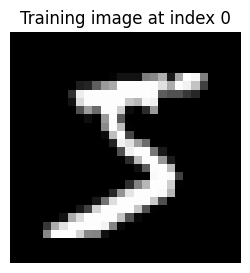

In [5]:
image_index = 0

plt.figure(figsize=(3, 3))
plt.imshow(train_images[image_index], cmap="gray", vmin=0, vmax=255)
plt.title(f"Training image at index {image_index}")
plt.axis("off")
plt.show()

In [6]:
label_filename = "train-labels-idx1-ubyte.gz"
label_url = "https://storage.googleapis.com/cvdf-datasets/mnist/" + label_filename
label_path = data_dir / label_filename

if not label_path.exists():
    print("Downloading MNIST training labels...")
    urlretrieve(label_url, label_path)

with gzip.open(label_path, "rb") as f:
    label_header = f.read(8)

label_magic, number_of_labels = struct.unpack(">II", label_header)

print("Magic number:", label_magic)
print("Number of labels:", number_of_labels)

Magic number: 2049
Number of labels: 60000


In [7]:
with gzip.open(label_path, "rb") as f:
    f.read(8)
    raw_labels = f.read()

train_labels = np.frombuffer(raw_labels, dtype=np.uint8)

assert len(train_labels) == number_of_images
print("Label for image", image_index, "is:", train_labels[image_index])

Label for image 0 is: 5


In [8]:
image_16 = train_images[image_index].astype(np.uint16)

pooled_image = (
    image_16[0::2, 0::2] +
    image_16[0::2, 1::2] +
    image_16[1::2, 0::2] +
    image_16[1::2, 1::2]
) >> 2

print("Original shape:", image_16.shape)
print("Pooled shape:", pooled_image.shape)

first_block = image_16[0:2, 0:2]

print("First 2x2 input block:")
print(first_block)
print("Manual average:", first_block.sum() // 4)
print("Pooled output [0, 0]:", pooled_image[0, 0])

Original shape: (28, 28)
Pooled shape: (14, 14)
First 2x2 input block:
[[0 0]
 [0 0]]
Manual average: 0
Pooled output [0, 0]: 0


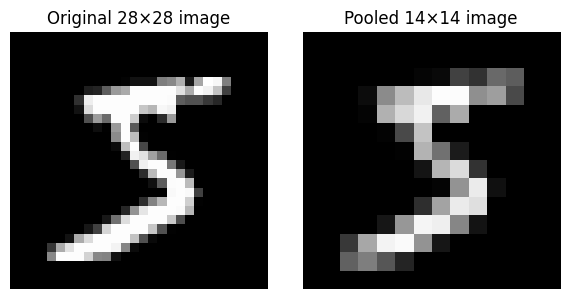

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(train_images[image_index], cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original 28×28 image")
axes[0].axis("off")

axes[1].imshow(pooled_image, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Pooled 14×14 image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [10]:
pooled_vector = pooled_image.reshape(-1)

row = 3
column = 5
flat_index = row * 14 + column

print("Flattened shape:", pooled_vector.shape)
print("Value at pooled_image[3, 5]:", pooled_image[row, column])
print("Value at pooled_vector[47]:", pooled_vector[flat_index])

Flattened shape: (196,)
Value at pooled_image[3, 5]: 188
Value at pooled_vector[47]: 188


In [11]:
example_inputs = np.array([10, -3, 20, -7], dtype=np.int16)
example_weights = np.array([-2, 5, -4, -6], dtype=np.int8)
example_bias = np.int8(9)

products = (
    example_inputs.astype(np.int32) *
    example_weights.astype(np.int32)
)

accumulator = products.sum(dtype=np.int32)
neuron_result = accumulator + np.int32(example_bias)

print("Inputs:      ", example_inputs)
print("Weights:     ", example_weights)
print("Products:    ", products)
print("Accumulator: ", accumulator)
print("Bias:        ", example_bias)
print("Final output:", neuron_result)

Inputs:       [10 -3 20 -7]
Weights:      [-2  5 -4 -6]
Products:     [-20 -15 -80  42]
Accumulator:  -73
Bias:         9
Final output: -64


In [12]:
example_weight_matrix = np.array(
    [
        [-2,  5, -4, -6],
        [ 1, -3,  2,  4],
        [-1, -2,  3, -4],
    ],
    dtype=np.int8
)

example_biases = np.array([9, -5, 8], dtype=np.int8)

dense_accumulators = (
    example_weight_matrix.astype(np.int32) @
    example_inputs.astype(np.int32)
)

dense_outputs = dense_accumulators + example_biases.astype(np.int32)

print("Weight-matrix shape:", example_weight_matrix.shape)
print("Dense accumulators:", dense_accumulators)
print("Dense outputs:     ", dense_outputs)

Weight-matrix shape: (3, 4)
Dense accumulators: [-73  31  84]
Dense outputs:      [-64  26  92]


In [13]:
def rtl_relu_shift_saturate(accumulator, shift=6):
    nonnegative = np.maximum(accumulator, 0)
    shifted = nonnegative >> shift
    saturated = np.minimum(shifted, np.iinfo(np.int16).max)
    return saturated.astype(np.int16)


relu_test_values = np.array(
    [-64, 26, 92, 64, 2_097_152],
    dtype=np.int32
)

relu_test_output = rtl_relu_shift_saturate(relu_test_values)

print("ReLU input: ", relu_test_values)
print("ReLU output:", relu_test_output)

ReLU input:  [    -64      26      92      64 2097152]
ReLU output: [    0     0     1     1 32767]


In [14]:
def rtl_argmax_last_tie(scores):
    reversed_scores = scores[::-1]
    reversed_max_index = np.argmax(reversed_scores)
    original_max_index = len(scores) - 1 - reversed_max_index
    return original_max_index


example_scores = np.array([3, 8, 8, 2], dtype=np.int16)

predicted_digit = rtl_argmax_last_tie(example_scores)

print("Class scores:   ", example_scores)
print("Predicted digit:", predicted_digit)

Class scores:    [3 8 8 2]
Predicted digit: 2


In [15]:
def rtl_average_pool_batch(images):
    images_16 = images.astype(np.uint16)

    pooled = (
        images_16[:, 0::2, 0::2] +
        images_16[:, 0::2, 1::2] +
        images_16[:, 1::2, 0::2] +
        images_16[:, 1::2, 1::2]
    ) >> 2

    return pooled


pooled_train_images = rtl_average_pool_batch(train_images)
train_vectors = pooled_train_images.reshape(number_of_images, -1)

print("Pooled batch shape:", pooled_train_images.shape)
print("Dense-input shape: ", train_vectors.shape)
print("Single-image and batch pooling match:",
      np.array_equal(pooled_image, pooled_train_images[image_index]))

Pooled batch shape: (60000, 14, 14)
Dense-input shape:  (60000, 196)
Single-image and batch pooling match: True


In [16]:
train_inputs = train_vectors.astype(np.float32) / 255.0

print("Training-input shape:", train_inputs.shape)
print("Data type:", train_inputs.dtype)
print("Value range:", train_inputs.min(), "to", train_inputs.max())

Training-input shape: (60000, 196)
Data type: float32
Value range: 0.0 to 1.0


In [17]:
def one_hot(labels, number_of_classes=10):
    encoded = np.zeros(
        (len(labels), number_of_classes),
        dtype=np.float32
    )

    encoded[np.arange(len(labels)), labels] = 1.0
    return encoded


train_targets = one_hot(train_labels)

print("Target shape:", train_targets.shape)
print("First label:  ", train_labels[0])
print("First target: ", train_targets[0])

Target shape: (60000, 10)
First label:   5
First target:  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [18]:
rng = np.random.default_rng(28)

input_features = 196
hidden_neurons = 32
output_neurons = 10

W1 = (
    rng.standard_normal((input_features, hidden_neurons))
    * np.sqrt(2.0 / input_features)
).astype(np.float32)

W2 = (
    rng.standard_normal((hidden_neurons, output_neurons))
    * np.sqrt(2.0 / hidden_neurons)
).astype(np.float32)

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)

W1 shape: (196, 32)
W2 shape: (32, 10)


In [19]:
def relu_float(values):
    return np.maximum(values, 0.0)


def forward_model(inputs):
    hidden_pre_activation = inputs @ W1
    hidden_activation = relu_float(hidden_pre_activation)

    output_pre_activation = hidden_activation @ W2
    output_activation = relu_float(output_pre_activation)

    return (
        hidden_pre_activation,
        hidden_activation,
        output_pre_activation,
        output_activation,
    )


z1, a1, z2, a2 = forward_model(train_inputs[:5])

print("z1 shape:", z1.shape)
print("a1 shape:", a1.shape)
print("z2 shape:", z2.shape)
print("a2 shape:", a2.shape)

z1 shape: (5, 32)
a1 shape: (5, 32)
z2 shape: (5, 10)
a2 shape: (5, 10)


In [20]:
def softmax(scores):
    shifted_scores = scores - scores.max(axis=1, keepdims=True)
    exponentials = np.exp(shifted_scores)
    return exponentials / exponentials.sum(axis=1, keepdims=True)


def argmax_last_tie_batch(scores):
    reversed_scores = scores[:, ::-1]
    reversed_max_indices = np.argmax(reversed_scores, axis=1)
    return scores.shape[1] - 1 - reversed_max_indices


probabilities = softmax(a2)
initial_predictions = argmax_last_tie_batch(probabilities)
initial_accuracy = np.mean(initial_predictions == train_labels[:5])

print("Probability shape:", probabilities.shape)
print("Predictions:", initial_predictions)
print("True labels:", train_labels[:5])
print("Accuracy on these five untrained examples:", initial_accuracy)

Probability shape: (5, 10)
Predictions: [1 1 8 5 8]
True labels: [5 0 4 1 9]
Accuracy on these five untrained examples: 0.0


In [21]:
def cross_entropy(probabilities, targets):
    safe_probabilities = np.clip(probabilities, 1e-9, 1.0)
    losses_per_image = -np.sum(
        targets * np.log(safe_probabilities),
        axis=1
    )
    return losses_per_image.mean()


first_five_targets = train_targets[:5]
initial_loss = cross_entropy(probabilities, first_five_targets)

print("Initial cross-entropy loss:", initial_loss)

Initial cross-entropy loss: 2.3369668


In [22]:
batch_size = len(first_five_targets)

gradient_after_output_relu = (
    probabilities - first_five_targets
) / batch_size

gradient_before_output_relu = (
    gradient_after_output_relu *
    (z2 > 0)
)

print("Gradient shape:", gradient_before_output_relu.shape)
print("Gradient for image 0:")
print(gradient_before_output_relu[0])

Gradient shape: (5, 10)
Gradient for image 0:
[ 0.01612998  0.02835038  0.          0.          0.01925978 -0.17777507
  0.01806079  0.02514842  0.          0.02356115]


In [23]:
gradient_W2 = a1.T @ gradient_before_output_relu

print("W2 shape:         ", W2.shape)
print("Gradient W2 shape:", gradient_W2.shape)
print("Gradient for hidden neuron 0:")
print(gradient_W2[0])

W2 shape:          (32, 10)
Gradient W2 shape: (32, 10)
Gradient for hidden neuron 0:
[ 0.          0.0141001   0.00069767  0.00056824 -0.00532827  0.00814247
  0.00701978  0.01070844  0.00078001  0.00957264]


In [24]:
gradient_after_hidden_relu = (
    gradient_before_output_relu @ W2.T
)

gradient_before_hidden_relu = (
    gradient_after_hidden_relu *
    (z1 > 0)
)

print("Gradient after hidden ReLU shape: ", gradient_after_hidden_relu.shape)
print("Gradient before hidden ReLU shape:", gradient_before_hidden_relu.shape)
print("Image 0 hidden-layer gradient:")
print(gradient_before_hidden_relu[0])

Gradient after hidden ReLU shape:  (5, 32)
Gradient before hidden ReLU shape: (5, 32)
Image 0 hidden-layer gradient:
[-0.         -0.01504916  0.00551683 -0.00922971 -0.02475725 -0.07590727
  0.05010671 -0.          0.          0.         -0.02750166 -0.
 -0.09319442  0.00708617 -0.05554872 -0.03473811 -0.         -0.04627797
  0.05604566  0.05245734 -0.          0.          0.         -0.04032216
  0.          0.         -0.          0.00956552  0.00747254  0.02282085
  0.10150862 -0.02555425]


In [25]:
first_five_inputs = train_inputs[:5]

gradient_W1 = (
    first_five_inputs.T @ gradient_before_hidden_relu
)

print("W1 shape:         ", W1.shape)
print("Gradient W1 shape:", gradient_W1.shape)
print("Gradient for input feature 0:")
print(gradient_W1[0])

W1 shape:          (196, 32)
Gradient W1 shape: (196, 32)
Gradient for input feature 0:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


In [26]:
learning_rate = 0.03

W1 = W1 - learning_rate * gradient_W1
W2 = W2 - learning_rate * gradient_W2

_, _, _, updated_a2 = forward_model(first_five_inputs)
updated_probabilities = softmax(updated_a2)
updated_loss = cross_entropy(
    updated_probabilities,
    first_five_targets
)

print("Loss before one update:", initial_loss)
print("Loss after one update: ", updated_loss)

Loss before one update: 2.3369668
Loss after one update:  2.2921824


In [28]:
def train_one_batch(inputs, targets, W1, W2, learning_rate):
    batch_size = len(inputs)

    z1 = inputs @ W1
    a1 = relu_float(z1)

    z2 = a1 @ W2
    a2 = relu_float(z2)

    probabilities = softmax(a2)
    loss = cross_entropy(probabilities, targets)

    gradient_z2 = (
        (probabilities - targets) / batch_size
    ) * (z2 > 0)

    gradient_W2 = a1.T @ gradient_z2

    gradient_a1 = gradient_z2 @ W2.T
    gradient_z1 = gradient_a1 * (z1 > 0)

    gradient_W1 = inputs.T @ gradient_z1

    W1 = W1 - learning_rate * gradient_W1
    W2 = W2 - learning_rate * gradient_W2

    return W1, W2, loss

In [29]:
batch_inputs = train_inputs[:128]
batch_targets = train_targets[:128]

W1, W2, batch_loss_before = train_one_batch(
    batch_inputs,
    batch_targets,
    W1,
    W2,
    learning_rate
)

_, _, _, batch_outputs_after = forward_model(batch_inputs)
batch_probabilities_after = softmax(batch_outputs_after)
batch_loss_after = cross_entropy(
    batch_probabilities_after,
    batch_targets
)

print("Batch loss before update:", batch_loss_before)
print("Batch loss after update: ", batch_loss_after)

Batch loss before update: 2.3805652
Batch loss after update:  2.3729224


In [30]:
def train_one_epoch(inputs, targets, W1, W2, learning_rate, batch_size):
    shuffled_indices = rng.permutation(len(inputs))
    batch_losses = []

    for start in range(0, len(inputs), batch_size):
        batch_indices = shuffled_indices[start:start + batch_size]

        batch_inputs = inputs[batch_indices]
        batch_targets = targets[batch_indices]

        W1, W2, batch_loss = train_one_batch(
            batch_inputs,
            batch_targets,
            W1,
            W2,
            learning_rate
        )

        batch_losses.append(batch_loss)

    mean_epoch_loss = np.mean(batch_losses)

    return W1, W2, mean_epoch_loss

In [32]:
W1, W2, epoch_1_loss = train_one_epoch(
    train_inputs,
    train_targets,
    W1,
    W2,
    learning_rate,
    batch_size=128
)

print("Epoch 1 mean loss:", epoch_1_loss)

Epoch 1 mean loss: 0.6293845


In [34]:
def predict_digits(inputs):
    _, _, _, output_scores = forward_model(inputs)
    return argmax_last_tie_batch(output_scores)


train_predictions = predict_digits(train_inputs)
train_accuracy = np.mean(train_predictions == train_labels)

print("Training accuracy after epoch 1:", train_accuracy)

Training accuracy after epoch 1: 0.8650166666666667


In [35]:
mnist_base_url = "https://storage.googleapis.com/cvdf-datasets/mnist/"

test_image_filename = "t10k-images-idx3-ubyte.gz"
test_label_filename = "t10k-labels-idx1-ubyte.gz"

test_image_path = data_dir / test_image_filename
test_label_path = data_dir / test_label_filename

for filename, path in [
    (test_image_filename, test_image_path),
    (test_label_filename, test_label_path),
]:
    if not path.exists():
        print("Downloading", filename)
        urlretrieve(mnist_base_url + filename, path)

print("Test files are ready.")

Test files are ready.


In [36]:
def read_mnist_images(path):
    with gzip.open(path, "rb") as f:
        magic, count, rows, columns = struct.unpack(">IIII", f.read(16))
        pixel_bytes = f.read()

    assert magic == 2051
    return np.frombuffer(
        pixel_bytes,
        dtype=np.uint8
    ).reshape(count, rows, columns)


def read_mnist_labels(path):
    with gzip.open(path, "rb") as f:
        magic, count = struct.unpack(">II", f.read(8))
        label_bytes = f.read()

    assert magic == 2049
    return np.frombuffer(label_bytes, dtype=np.uint8)


test_images = read_mnist_images(test_image_path)
test_labels = read_mnist_labels(test_label_path)

print("Test-image shape:", test_images.shape)
print("Test-label shape:", test_labels.shape)

Test-image shape: (10000, 28, 28)
Test-label shape: (10000,)


In [38]:
pooled_test_images = rtl_average_pool_batch(test_images)

test_vectors = pooled_test_images.reshape(
    len(test_images),
    -1
)

test_inputs = test_vectors.astype(np.float32) / 255.0

print("Pooled test shape:", pooled_test_images.shape)
print("Dense-input shape:", test_inputs.shape)
print("Test range:", test_inputs.min(), "to", test_inputs.max())

Pooled test shape: (10000, 14, 14)
Dense-input shape: (10000, 196)
Test range: 0.0 to 1.0


In [39]:
test_predictions = predict_digits(test_inputs)

test_accuracy = np.mean(
    test_predictions == test_labels
)

print("Training accuracy after epoch 1:", train_accuracy)
print("Test accuracy after epoch 1:    ", test_accuracy)

Training accuracy after epoch 1: 0.8650166666666667
Test accuracy after epoch 1:     0.8738


In [40]:
loss_history = [epoch_1_loss]
train_accuracy_history = [train_accuracy]
test_accuracy_history = [test_accuracy]

additional_epochs = 9

for epoch_offset in range(additional_epochs):
    W1, W2, mean_loss = train_one_epoch(
        train_inputs,
        train_targets,
        W1,
        W2,
        learning_rate,
        batch_size=128
    )

    train_predictions = predict_digits(train_inputs)
    test_predictions = predict_digits(test_inputs)

    current_train_accuracy = np.mean(
        train_predictions == train_labels
    )
    current_test_accuracy = np.mean(
        test_predictions == test_labels
    )

    loss_history.append(mean_loss)
    train_accuracy_history.append(current_train_accuracy)
    test_accuracy_history.append(current_test_accuracy)

    epoch_number = epoch_offset + 2

    print(
        f"Epoch {epoch_number:02d} | "
        f"loss={mean_loss:.4f} | "
        f"train={current_train_accuracy:.2%} | "
        f"test={current_test_accuracy:.2%}"
    )

Epoch 02 | loss=0.4646 | train=88.41% | test=89.16%
Epoch 03 | loss=0.4058 | train=89.25% | test=90.04%
Epoch 04 | loss=0.3742 | train=89.81% | test=90.29%
Epoch 05 | loss=0.3537 | train=90.30% | test=90.79%
Epoch 06 | loss=0.3388 | train=90.59% | test=91.24%
Epoch 07 | loss=0.3271 | train=90.85% | test=91.45%
Epoch 08 | loss=0.3171 | train=91.07% | test=91.71%
Epoch 09 | loss=0.3087 | train=91.33% | test=91.90%
Epoch 10 | loss=0.3011 | train=91.55% | test=91.95%


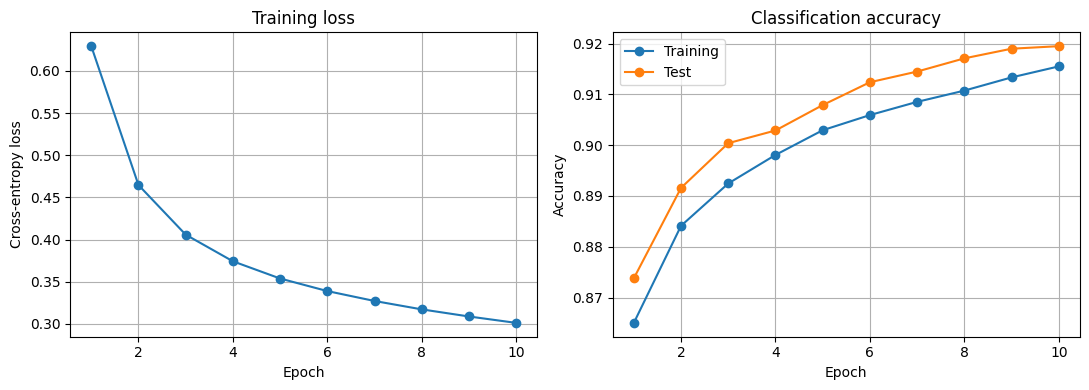

In [41]:
epoch_numbers = np.arange(
    1,
    len(loss_history) + 1
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epoch_numbers, loss_history, marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].grid()

axes[1].plot(
    epoch_numbers,
    train_accuracy_history,
    marker="o",
    label="Training"
)
axes[1].plot(
    epoch_numbers,
    test_accuracy_history,
    marker="o",
    label="Test"
)
axes[1].set_title("Classification accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [42]:
print("W1 minimum:", W1.min())
print("W1 maximum:", W1.max())
print("W1 largest absolute value:", np.abs(W1).max())

print("W2 minimum:", W2.min())
print("W2 maximum:", W2.max())
print("W2 largest absolute value:", np.abs(W2).max())

W1 minimum: -0.5484097
W1 maximum: 0.73464364
W1 largest absolute value: 0.73464364
W2 minimum: -1.2326572
W2 maximum: 1.3058618
W2 largest absolute value: 1.3058618


In [43]:
INT8_MAX = 127

def quantize_weights_to_int8(weights):
    largest_magnitude = np.abs(weights).max()

    scale = INT8_MAX / largest_magnitude

    scaled_weights = weights * scale
    clipped_weights = np.clip(
        scaled_weights,
        -INT8_MAX,
        INT8_MAX
    )

    quantized_weights = np.rint(
        clipped_weights
    ).astype(np.int8)

    reconstructed_weights = (
        quantized_weights.astype(np.float32) / scale
    )

    return quantized_weights, scale, reconstructed_weights


W1_q, W1_scale, W1_reconstructed = quantize_weights_to_int8(W1)
W2_q, W2_scale, W2_reconstructed = quantize_weights_to_int8(W2)

print("W1 scale:", W1_scale)
print("W1 int8 range:", W1_q.min(), "to", W1_q.max())
print("W1 maximum quantization error:",
      np.abs(W1 - W1_reconstructed).max())

print("W2 scale:", W2_scale)
print("W2 int8 range:", W2_q.min(), "to", W2_q.max())
print("W2 maximum quantization error:",
      np.abs(W2 - W2_reconstructed).max())

W1 scale: 172.87292
W1 int8 range: -95 to 127
W1 maximum quantization error: 0.0028918236
W2 scale: 97.253784
W2 int8 range: -120 to 127
W2 maximum quantization error: 0.0051330924


In [45]:
def forward_quantized_float(inputs):
    z1 = inputs @ W1_reconstructed
    a1 = relu_float(z1)

    z2 = a1 @ W2_reconstructed
    a2 = relu_float(z2)

    return a2


quantized_float_scores = forward_quantized_float(test_inputs)

quantized_float_predictions = argmax_last_tie_batch(
    quantized_float_scores
)

quantized_float_accuracy = np.mean(
    quantized_float_predictions == test_labels
)

print("Original float-model accuracy:  ", test_accuracy)
print("Int8-weight float-model accuracy:", quantized_float_accuracy)

In [47]:
final_float_predictions = predict_digits(test_inputs)

final_float_accuracy = np.mean(
    final_float_predictions == test_labels
)

print("Final float-model accuracy:      ", final_float_accuracy)
print("Int8-weight float-model accuracy:", quantized_float_accuracy)
print(
    "Accuracy change from weight quantization:",
    quantized_float_accuracy - final_float_accuracy
)

Final float-model accuracy:       0.9195
Int8-weight float-model accuracy: 0.9196
Accuracy change from weight quantization: 9.999999999998899e-05


In [48]:
B1_q = np.zeros(32, dtype=np.int8)
B2_q = np.zeros(10, dtype=np.int8)


def rtl_dense_integer(inputs, weights, biases):
    accumulator_64 = (
        inputs.astype(np.int64) @
        weights.astype(np.int64)
    ) + biases.astype(np.int64)

    int32_min = -(2 ** 31)
    int32_max = (2 ** 31) - 1

    assert accumulator_64.min() >= int32_min
    assert accumulator_64.max() <= int32_max

    return accumulator_64.astype(np.int32)


test_acc1 = rtl_dense_integer(
    test_vectors,
    W1_q,
    B1_q
)

test_act1 = rtl_relu_shift_saturate(
    test_acc1,
    shift=6
)

print("Dense-1 accumulator shape:", test_acc1.shape)
print("Dense-1 accumulator range:",
      test_acc1.min(), "to", test_acc1.max())

print("Dense-1 activation shape:", test_act1.shape)
print("Dense-1 activation range:",
      test_act1.min(), "to", test_act1.max())

Dense-1 accumulator shape: (10000, 32)
Dense-1 accumulator range: -188009 to 369680
Dense-1 activation shape: (10000, 32)
Dense-1 activation range: 0 to 5776


In [49]:
# Dense-2: 32 signed-16-bit activations × signed-int8 weights → signed-int32 accumulator.
test_acc2 = rtl_dense_integer(test_act1, W2_q, B2_q)

# Apply the same RTL ReLU, right shift, and signed-16-bit saturation.
test_act2 = rtl_relu_shift_saturate(test_acc2, shift=6)

print("Dense-2 accumulator shape:", test_acc2.shape)
print("Dense-2 accumulator range:", test_acc2.min(), "to", test_acc2.max())
print("Dense-2 activation shape:", test_act2.shape)
print("Dense-2 activation range:", test_act2.min(), "to", test_act2.max())

Dense-2 accumulator shape: (10000, 10)
Dense-2 accumulator range: -931229 to 1527713
Dense-2 activation shape: (10000, 10)
Dense-2 activation range: 0 to 23870


In [50]:
# Mirror select_max.sv: when scores tie, choose the highest digit index.
rtl_matched_predictions = argmax_last_tie_batch(test_act2)

# Compare one predicted digit per test image with the known MNIST label.
rtl_matched_accuracy = np.mean(rtl_matched_predictions == test_labels)

print("RTL-matched integer-model accuracy:", rtl_matched_accuracy)
print("RTL-matched integer-model accuracy: "
      f"{rtl_matched_accuracy * 100:.2f}%")

print("First 20 predictions:", rtl_matched_predictions[:20])
print("First 20 true labels: ", test_labels[:20])

RTL-matched integer-model accuracy: 0.9196
RTL-matched integer-model accuracy: 91.96%
First 20 predictions: [7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]
First 20 true labels:  [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [53]:
# Count activations that reached the signed-16-bit saturation limit.
INT16_MAX = np.iinfo(np.int16).max

dense1_saturation_count = np.count_nonzero(test_act1 == INT16_MAX)
dense2_saturation_count = np.count_nonzero(test_act2 == INT16_MAX)

print("Dense-1 saturated activations:", dense1_saturation_count)
print("Dense-2 saturated activations:", dense2_saturation_count)

Dense-1 saturated activations: 0
Dense-2 saturated activations: 0


In [56]:
# Confirm that both prediction arrays contain one class index per test image.
print("Quantized-float prediction shape:", quantized_float_predictions.shape)
print("RTL-matched prediction shape:    ", rtl_matched_predictions.shape)

# Find the positions whose predicted digit differs between the two models.
prediction_mismatch_indices = np.flatnonzero(
    quantized_float_predictions != rtl_matched_predictions
)

# Report the total number of differing predictions.
print("Prediction mismatches:", len(prediction_mismatch_indices))

# Display up to the first ten mismatch locations for inspection.
print("First mismatch indices:", prediction_mismatch_indices[:10])

# For those same images, show float prediction, integer prediction, and true MNIST label.
first_mismatch_indices = prediction_mismatch_indices[:10]
print("Quantized-float predictions:", quantized_float_predictions[first_mismatch_indices])
print("RTL-matched predictions:   ", rtl_matched_predictions[first_mismatch_indices])
print("True labels:                ", test_labels[first_mismatch_indices])

Quantized-float prediction shape: (10000,)
RTL-matched prediction shape:     (10000,)
Prediction mismatches: 2
First mismatch indices: [2183 9017]
Quantized-float predictions: [4 8]
RTL-matched predictions:    [6 1]
True labels:                 [4 1]


In [58]:
def rtl_inference_trace(image_vector):
    # Convert the selected flattened pooled image to signed 16-bit dense input.
    dense1_input = image_vector.astype(np.int16)

    # Add a batch dimension because rtl_dense_integer expects rows of images.
    dense1_accumulator = rtl_dense_integer(
        dense1_input[np.newaxis, :], W1_q, B1_q
    )[0]

    # Apply the exact first RTL ReLU, right shift, and int16 saturation rule.
    dense1_activation = rtl_relu_shift_saturate(
        dense1_accumulator, shift=6
    )

    # Add a batch dimension because Dense-2 also expects a batch of input rows.
    dense2_accumulator = rtl_dense_integer(
        dense1_activation[np.newaxis, :], W2_q, B2_q
    )[0]

    # Apply the same RTL activation rule after the second dense layer.
    dense2_scores = rtl_relu_shift_saturate(
        dense2_accumulator, shift=6
    )

    # Use the single-image highest-index-on-tie rule matching select_max.sv.
    prediction = rtl_argmax_last_tie(dense2_scores)

    # Return every module-boundary value under a descriptive name.
    return {
        "dense1_input": dense1_input,
        "dense1_accumulator": dense1_accumulator,
        "dense1_activation": dense1_activation,
        "dense2_accumulator": dense2_accumulator,
        "dense2_scores": dense2_scores,
        "prediction": prediction,
    }

In [59]:
# Choose one test image to use as the first RTL comparison case.
trace_index = 0

# Run the selected raw pooled vector through the single-image integer trace.
golden_trace = rtl_inference_trace(test_vectors[trace_index])

# Confirm that the trace result agrees with the existing batch inference result.
assert golden_trace["prediction"] == rtl_matched_predictions[trace_index]

# Print the model decision beside MNIST's known label.
print("Test index:", trace_index)
print("True label:", test_labels[trace_index])
print("Golden RTL-matched prediction:", golden_trace["prediction"])

# Print the final ten scores that select_max will compare.
print("Dense-2 ReLU scores:", golden_trace["dense2_scores"])

# Print each trace array's shape so the RTL comparison dimensions are explicit.
for name, value in golden_trace.items():
    if isinstance(value, np.ndarray):
        print(f"{name}: shape={value.shape}, dtype={value.dtype}")

Test index: 0
True label: 7
Golden RTL-matched prediction: 7
Dense-2 ReLU scores: [ 3607     0  4474  5911     0  1258     0 12049  2045  5526]
dense1_input: shape=(196,), dtype=int16
dense1_accumulator: shape=(32,), dtype=int32
dense1_activation: shape=(32,), dtype=int16
dense2_accumulator: shape=(10,), dtype=int32
dense2_scores: shape=(10,), dtype=int16


In [60]:
# Check that the trace input is the same raw pooled vector used by batch inference.
assert np.array_equal(
    golden_trace["dense1_input"],
    test_vectors[trace_index].astype(np.int16),
)

# Check Dense-1's 32 signed-32 accumulator values.
assert np.array_equal(
    golden_trace["dense1_accumulator"],
    test_acc1[trace_index],
)

# Check Dense-1's 32 signed-16 ReLU/shift/saturation outputs.
assert np.array_equal(
    golden_trace["dense1_activation"],
    test_act1[trace_index],
)

# Check Dense-2's 10 signed-32 accumulator values.
assert np.array_equal(
    golden_trace["dense2_accumulator"],
    test_acc2[trace_index],
)

# Check Dense-2's ten final signed-16 scores.
assert np.array_equal(
    golden_trace["dense2_scores"],
    test_act2[trace_index],
)

# Report success only if every hardware-boundary comparison passed.
print("PASS: single-image golden trace matches the batch RTL-matched reference.")

PASS: single-image golden trace matches the batch RTL-matched reference.


In [61]:
# Transpose Dense-1 from Python [feature, neuron] to RTL [neuron, feature].
W_ARRAY_L2_python = W1_q.T.copy()

# Transpose Dense-2 from Python [feature, neuron] to RTL [neuron, feature].
W_ARRAY_L3_python = W2_q.T.copy()

# Copy the zero-bias vectors in their existing neuron order.
B_ARRAY_L2_python = B1_q.copy()
B_ARRAY_L3_python = B2_q.copy()

# Verify the resulting layouts match the dimensions declared in RTL.
assert W_ARRAY_L2_python.shape == (32, 196)
assert W_ARRAY_L3_python.shape == (10, 32)
assert B_ARRAY_L2_python.shape == (32,)
assert B_ARRAY_L3_python.shape == (10,)

# Verify transposition did not change any weight-to-neuron connection.
assert W_ARRAY_L2_python[7, 42] == W1_q[42, 7]
assert W_ARRAY_L3_python[3, 11] == W2_q[11, 3]

# Verify every exported parameter fits the signed 8-bit RTL contract.
for values in (
    W_ARRAY_L2_python, W_ARRAY_L3_python,
    B_ARRAY_L2_python, B_ARRAY_L3_python,
):
    assert values.min() >= -128
    assert values.max() <= 127

# Report the validated RTL-ready dimensions.
print("L2 weights/biases:", W_ARRAY_L2_python.shape, B_ARRAY_L2_python.shape)
print("L3 weights/biases:", W_ARRAY_L3_python.shape, B_ARRAY_L3_python.shape)

L2 weights/biases: (32, 196) (32,)
L3 weights/biases: (10, 32) (10,)


In [64]:
# Convert one Python integer into an explicit signed 8-bit SystemVerilog literal.
def sv_int8_literal(value):
    return f"8'sd{int(value)}"

# Format one bias vector as an unpacked SystemVerilog assignment pattern.
def sv_1d_initializer(values):
    return "'{" + ", ".join(sv_int8_literal(value) for value in values) + "}"

# Format one neuron-first weight matrix as nested unpacked assignment patterns.
def sv_2d_initializer(matrix):
    rows = [
        "    '{" + ", ".join(sv_int8_literal(value) for value in row) + "}"
        for row in matrix
    ]
    return "'{\n" + ",\n".join(rows) + "\n}"

# Build the four exact initializer strings, without writing them to a file.
sv_B_ARRAY_L2 = sv_1d_initializer(B_ARRAY_L2_python)
sv_W_ARRAY_L2 = sv_2d_initializer(W_ARRAY_L2_python)
sv_B_ARRAY_L3 = sv_1d_initializer(B_ARRAY_L3_python)
sv_W_ARRAY_L3 = sv_2d_initializer(W_ARRAY_L3_python)

# Confirm the generated text begins with explicit signed-8 syntax.
print(sv_B_ARRAY_L2)
print(sv_B_ARRAY_L3)
print(sv_W_ARRAY_L2)
print(sv_W_ARRAY_L3)

'{8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0}
'{8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0, 8'sd0}
'{
    '{8'sd-21, 8'sd-14, 8'sd-7, 8'sd23, 8'sd-7, 8'sd12, 8'sd14, 8'sd34, 8'sd13, 8'sd0, 8'sd-30, 8'sd26, 8'sd-25, 8'sd9, 8'sd-13, 8'sd-24, 8'sd0, 8'sd4, 8'sd1, 8'sd30, 8'sd39, 8'sd-1, 8'sd15, 8'sd22, 8'sd11, 8'sd3, 8'sd8, 8'sd-13, 8'sd11, 8'sd-6, 8'sd27, 8'sd-1, 8'sd25, 8'sd22, 8'sd35, 8'sd10, 8'sd35, 8'sd-1, 8'sd-23, 8'sd-12, 8'sd-11, 8'sd23, 8'sd-34, 8'sd-11, 8'sd-15, 8'sd27, 8'sd20, 8'sd43, 8'sd25, 8'sd53, 8'sd49, 8'sd-4, 8'sd-3, 8'sd5, 8'sd7, 8'sd24, 8'sd-13, 8'sd27, 8'sd4, 8'sd14, 8'sd20, 8'sd67, 8'sd54, 8'sd50, 8'sd46, 8'sd38, 8'sd-4, 8'sd16, 8'sd23, 8'sd-11, 8'sd-4, 8'sd-19, 8'sd-10, 8'sd-15, 8'sd-26, 8'sd-30, 8'sd-41, 8'sd-51, 8'sd-50, 8'sd-35, 8'sd-8, 8'sd-43, 8'sd14, 8'sd-12, 8'sd4